In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import datetime

ERROR 1: PROJ: proj_create_from_database: Open of /nesi/project/niwa00018/queenle/ml_env_v2/share/proj failed


In [2]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)

In [3]:
# load input variable datasets
print('loading datasets')
cam5_vars = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/daily/inputs/FWI_inputs_All_ensMean.nc')
d4pdf_vars = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/FWI_inputs_HPB_ensMean_1951-2021.nc')
d4pdf_bc_wind = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/BC_wind/BC_WIND_HPB_ensMean_1951-2021.nc')
d4pdf_bc_wind = d4pdf_bc_wind.rename({'latitude':'lat','longitude':'lon'})
d4pdf_vars['bc_wind'] = d4pdf_bc_wind

era5_cam5_res = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/daily/cam5_resolution/FWI_inputs_daily_cam5_resolution.nc')
era5_d4pdf_res = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/daily/d4pdf_resolution/FWI_inputs_daily_d4pdf_resolution.nc')

# create vege masks 
vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf_vars.lon, latitude=d4pdf_vars.lat, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

cam5_vege = vege_ds_coarsened.interp(longitude=cam5_vars.lon, latitude=cam5_vars.lat, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

loading datasets


In [4]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)


In [4]:

# clip to study region
print('mask by vegetation and clip to region')
box = [(32,55),(232,256)]
cam5_vars = cam5_vars.where(cam5_vege_mask>0).sel(lat=slice(box[0][0],box[0][1]),lon=slice(box[1][0],box[1][1]))
d4pdf_vars = d4pdf_vars.where(d4pdf_vege_mask>0).sel(lat=slice(box[0][0],box[0][1]),lon=slice(box[1][0],box[1][1]))
era5_d4pdf_res = era5_d4pdf_res.where(d4pdf_vege_mask>0).sel(lat=slice(box[0][0],box[0][1]),lon=slice(box[1][0],box[1][1]))
era5_cam5_res = era5_cam5_res.where(cam5_vege_mask>0).sel(lat=slice(box[0][0],box[0][1]),lon=slice(box[1][0],box[1][1]))


mask by vegetation and clip to region


In [29]:
d4pdf_vege_mask

<xarray.DataArray (lat: 92, lon: 59)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan, 5.93755483,
        6.82870345],
       [       nan,        nan,        nan, ...,        nan, 5.44935667,
        7.0018532 ],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]])
Coordinates:
    longitude  (lon) float64 222.8 223.3 223.9 224.4 ... 253.7 254.2 254.8 255.4
    latitude   (lat) float64 19.94 20.5 21.06 21.62 ... 69.36 69.92 70.48 71.05
  * lon        (lon) float64 222.8 223.3 223.9 224.4 ... 253.7 254.2 254.8 255.4
  * lat        (lat) float64 19.94 20.5 21.06 21.62 ... 69.36 69.92 70.48 71.05

In [23]:
era5_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_inputs_6month_fire_season_d4pdf_resolution.nc').tp
era5_da = era5_da.rename({'longitude':'lon','latitude':'lat'})
box = [(32,55),(232,256)]
era5_ds = era5_da.sel(lat=slice(box[0][0],box[0][1]),lon=slice(box[1][0],box[1][1])).where(d4pdf_vege_mask>0)



In [32]:
era5_trend = xr.apply_ufunc(get_linregress_slope, era5_ds, input_core_dims=[["time"]], vectorize = True)


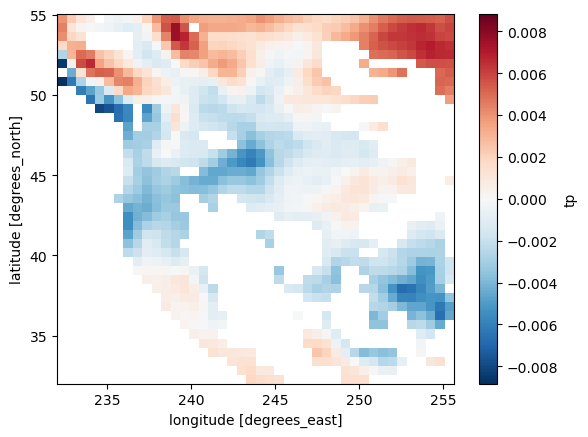

In [33]:
era5_trend.plot()

In [8]:
cam5_means = cam5_vars.sel(time=slice('1959','2014')).mean('time')
era5_cam5_means = era5_cam5_res.sel(time=slice('1959','2014')).mean('time')

d4pdf_means = d4pdf_vars.sel(time=slice('1951','2021')).mean('time')
era5_d4pdf_means = era5_d4pdf_res.sel(time=slice('1951','2021')).mean('time')


In [5]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }

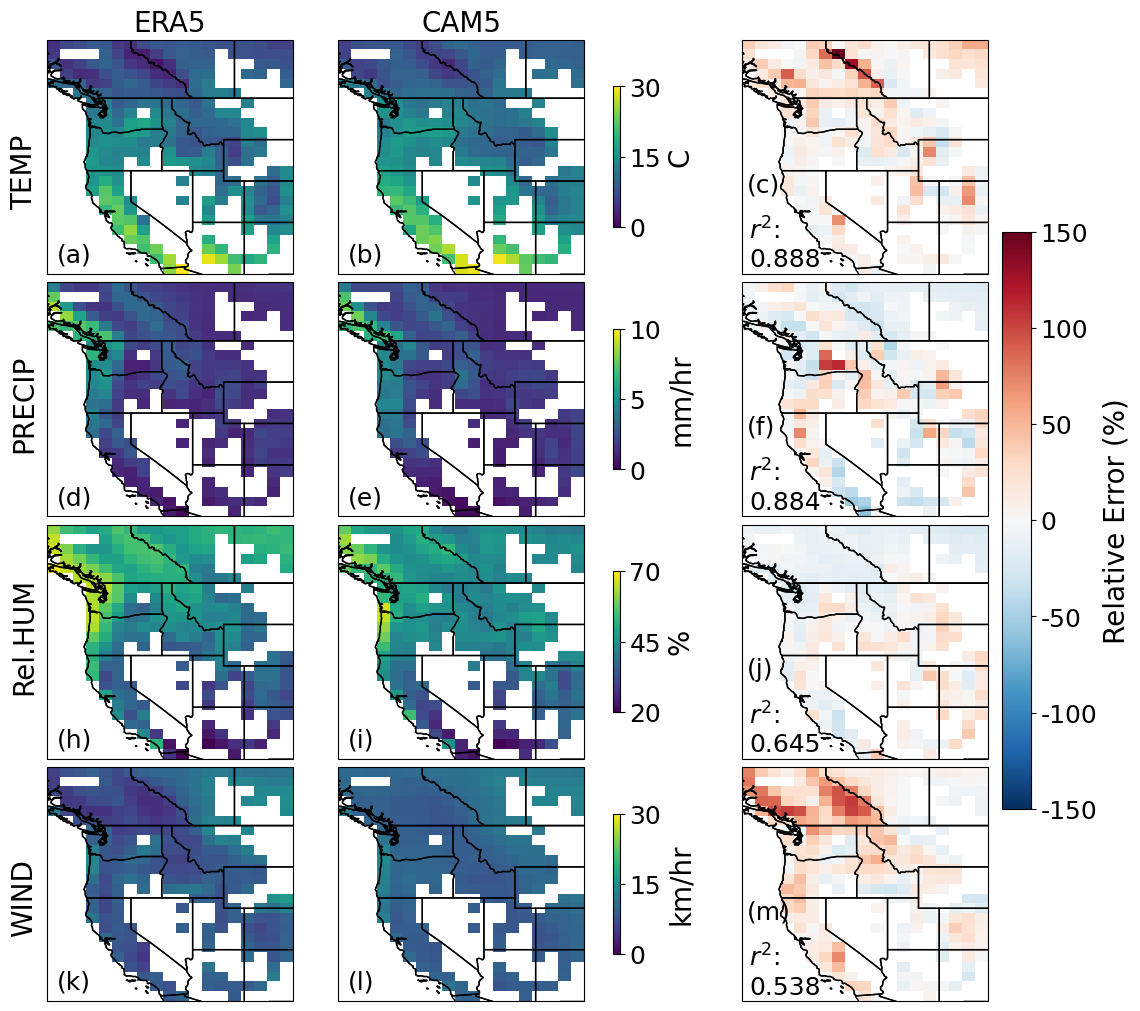

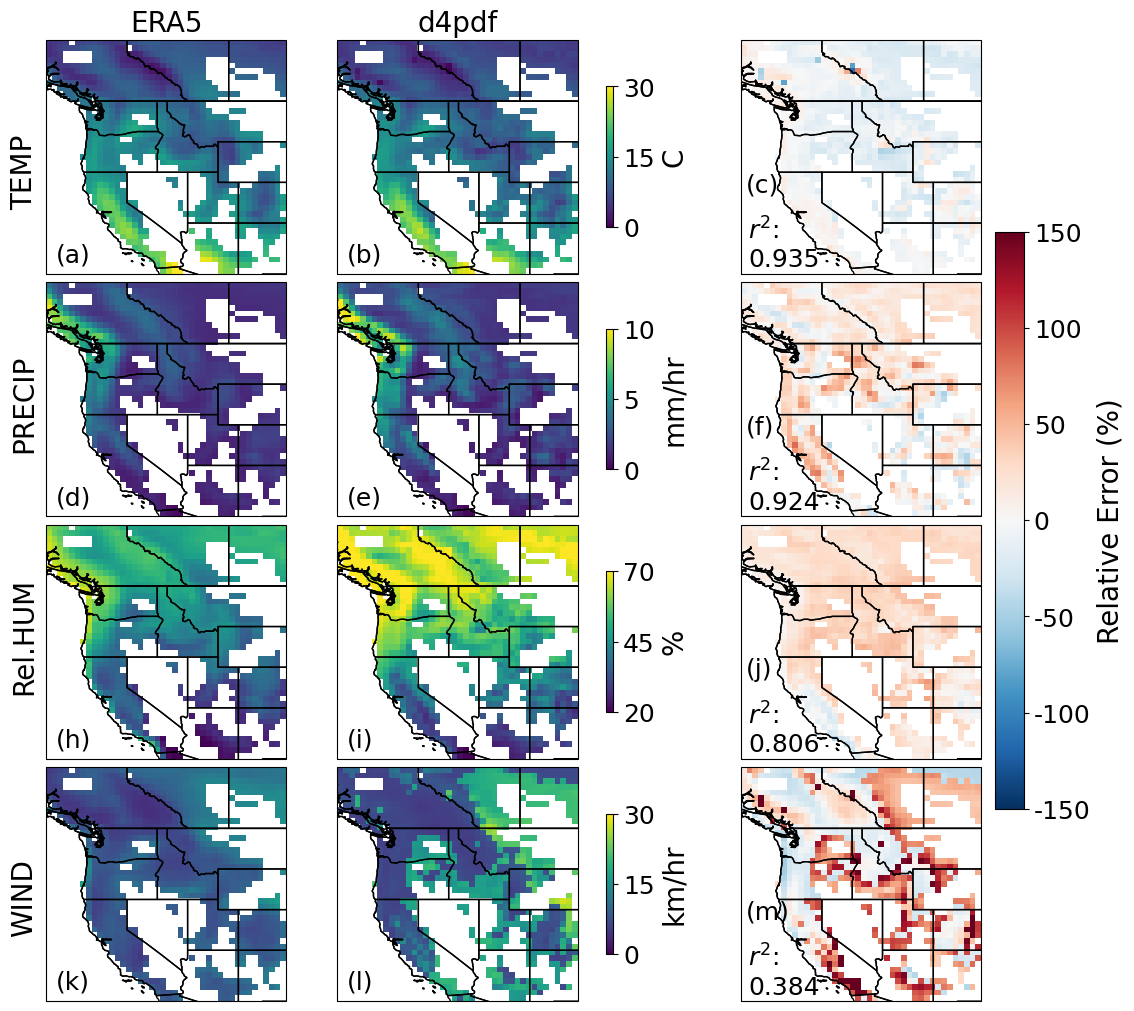

In [26]:
var_names = {'d4pdf':['ta','precipi','rha','wind'],'CAM5':['tasmax','pr','rh','wind'],'era5':['mx2t','tp','min_rh','wind']}
cb_ranges = {'TEMP':[0,30],'PRECIP':[0,10],'Rel.HUM':[20,70],'WIND':[0,30]}
cb_ticks = {'TEMP':[[0,15,30],['0','15','30']],'PRECIP':[[0,5,10],['0','5','10']],
            'Rel.HUM':[[20,45,70],['20','45','70']],'WIND':[[0,15,30],['0','15','30']]}
labels = {'TEMP':'C','PRECIP':'mm/hr','Rel.HUM':'%','WIND':'km/hr'}
subplot_labels = [['(a)','(b)','(c)'],
                  ['(d)','(e)','(f)'],
                  ['(h)','(i)','(j)'],
                  ['(k)','(l)','(m)']]

for m,model in enumerate(['CAM5','d4pdf']):
    fig,axs = plt.subplots(4,3,figsize=(11.3,10),layout='constrained',sharex=True,sharey=True,subplot_kw=dict(projection=ccrs.PlateCarree()))

    images = {'TEMP':[],'PRECIP':[],'Rel.HUM':[],'WIND':[]}

    for j,var in enumerate(['TEMP','PRECIP','Rel.HUM','WIND']):

        if model == 'd4pdf':
            era5_mean = era5_d4pdf_means[var_names['era5'][j]]
            model_mean = d4pdf_means[var_names[model][j]]
            error = ((model_mean - era5_mean)/era5_mean)*100

            era5_mean.plot(ax=axs[j][0],vmin=cb_ranges[var][0],vmax=cb_ranges[var][1],transform=ccrs.PlateCarree(),add_colorbar=False)

            images[var].append(model_mean.plot(ax=axs[j][1],vmin=cb_ranges[var][0],vmax=cb_ranges[var][1],transform=ccrs.PlateCarree(),add_colorbar=False))
            images[var].append(error.plot(ax=axs[j][2],cmap='RdBu_r',vmin=-150,vmax=150,transform=ccrs.PlateCarree(),add_colorbar=False))

            corr = xr.corr(model_mean,era5_mean).data**2

        elif model == 'CAM5':
            era5_mean = era5_cam5_means[var_names['era5'][j]]
            model_mean = cam5_means[var_names[model][j]]
            error = ((model_mean - era5_mean)/era5_mean)*100

            era5_mean.plot(ax=axs[j][0],vmin=cb_ranges[var][0],vmax=cb_ranges[var][1],transform=ccrs.PlateCarree(),add_colorbar=False)

            images[var].append(model_mean.plot(ax=axs[j][1],vmin=cb_ranges[var][0],vmax=cb_ranges[var][1],transform=ccrs.PlateCarree(),add_colorbar=False))
            images[var].append(error.plot(ax=axs[j][2],cmap='RdBu_r',vmin=-150,vmax=150,transform=ccrs.PlateCarree(),add_colorbar=False))

            corr = xr.corr(model_mean,era5_mean).data**2

        axs[j][0].text(0.04, 0.05, subplot_labels[j][0], size=18, color='black', transform=axs[j][0].transAxes)
        axs[j][1].text(0.04, 0.05, subplot_labels[j][1], size=18, color='black', transform=axs[j][1].transAxes)        
        axs[j][2].text(0.02, 0.35, subplot_labels[j][2], size=18, color='black', transform=axs[j][2].transAxes)        
        axs[j][2].text(0.03, 0.03, r'$r^2$' + f':\n{corr:.3f}', size=18, color='black', transform=axs[j][2].transAxes)
        

    for i,var in enumerate(['TEMP','PRECIP','Rel.HUM','WIND']):

        cb = fig.colorbar(images[var][0], ax=axs[i, 0:2], shrink=0.6,orientation='vertical')
        cb.set_label(labels[var],fontdict=font)

        font['size']=18
        cb.set_ticks(cb_ticks[var][0],labels=cb_ticks[var][1],fontdict=font)
        font['size']=20

        axs[i][0].text(-0.15,0.3,list(labels.keys())[i],fontdict=font,transform=axs[i][0].transAxes, rotation='vertical',ma='center')


    axs[0][0].set_title('ERA5',fontdict=font)
    axs[0][1].set_title(model,fontdict=font)

    cb = fig.colorbar(images['TEMP'][1], ax=axs[0:4, 2], shrink=0.6,orientation='vertical')
    cb.set_label('Relative Error (%)',fontdict=font)
    font['size']=18
    cb.set_ticks([-150+50*i for i in range(7)],labels=[str(-150+50*i) for i in range(7)],fontdict=font)
    font['size']=20

    for ax in axs.flatten():
        ax.coastlines()
        ax.add_feature(cf.BORDERS)
        ax.add_feature(cf.STATES)

    plt.savefig(f'/home/queenle/fire_attribution/figures/sup_mat/SM_Fig{m+3}.png',dpi=300)


In [ ]:
cam5_means = cam5_vars.mean('time')
d4pdf_means = d4pdf_vars.mean('time')
era5_d4pdf_means = era5_d4pdf_res.mean('time')
era5_cam5_means = era5_cam5_res.mean('time')


In [15]:
d4pdf_wind_trend = xr.apply_ufunc(get_linregress_slope, d4pdf_vars['wind'], input_core_dims=[["time"]], vectorize = True)*365
d4pdf_bcwind_trend = xr.apply_ufunc(get_linregress_slope, d4pdf_vars['bc_wind'], input_core_dims=[["time"]], vectorize = True)*365
era5_wind_trend = xr.apply_ufunc(get_linregress_slope, era5_d4pdf_res['wind'], input_core_dims=[["time"]], vectorize = True)*365


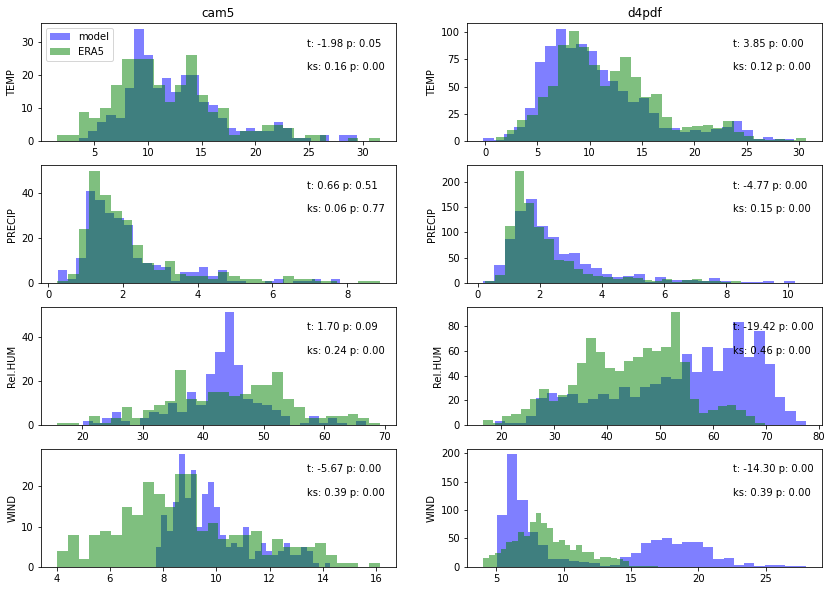

In [44]:
var_names = {'d4pdf':['ta','precipi','rha','wind'],'cam5':['tasmax','pr','rh','wind'],'era5':['mx2t','tp','min_rh','wind']}
cb_ranges = {'TEMP':[0,30],'PRECIP':[0,10],'Rel.HUM':[20,75],'WIND':[0,25]}
images = {}

fig,axs = plt.subplots(4,2,figsize=(14,10))

model = 'd4pdf'
for i,var in enumerate(['TEMP','PRECIP','Rel.HUM','WIND']):
    
    for j,model in enumerate(['cam5','d4pdf']):
        if model == 'd4pdf':
            model_data = d4pdf_means[var_names[model][i]].data.flatten()
            era5_data = era5_d4pdf_means[var_names['era5'][i]].data.flatten()
            
        elif model == 'cam5':
            model_data = cam5_means[var_names[model][i]].data.flatten()
            era5_data = era5_cam5_means[var_names['era5'][i]].data.flatten()
            
        model_data = model_data[~np.isnan(model_data)]
        era5_data = era5_data[~np.isnan(era5_data)]

        axs[i][j].hist(model_data,label='model',color='blue',alpha=0.5,bins=30)
        axs[i][j].hist(era5_data,label='ERA5',color='green',alpha=0.5,bins=30)
        
        t_stat, t_p_value = stats.ttest_ind(era5_data,model_data)
        ks_stat, ks_p_value = stats.kstest(era5_data,model_data)

        axs[i][j].text(0.75,0.8,f't: {t_stat:.2f} p: {t_p_value:.2f}',transform=axs[i][j].transAxes)
        axs[i][j].text(0.75,0.6,f'ks: {ks_stat:.2f} p: {ks_p_value:.2f}',transform=axs[i][j].transAxes)
        
        if i == 0:
            axs[i][j].set_title(model)
            if j == 0:
                axs[i][j].legend(loc='upper left')
            
        axs[i][j].set_ylabel(var)
        


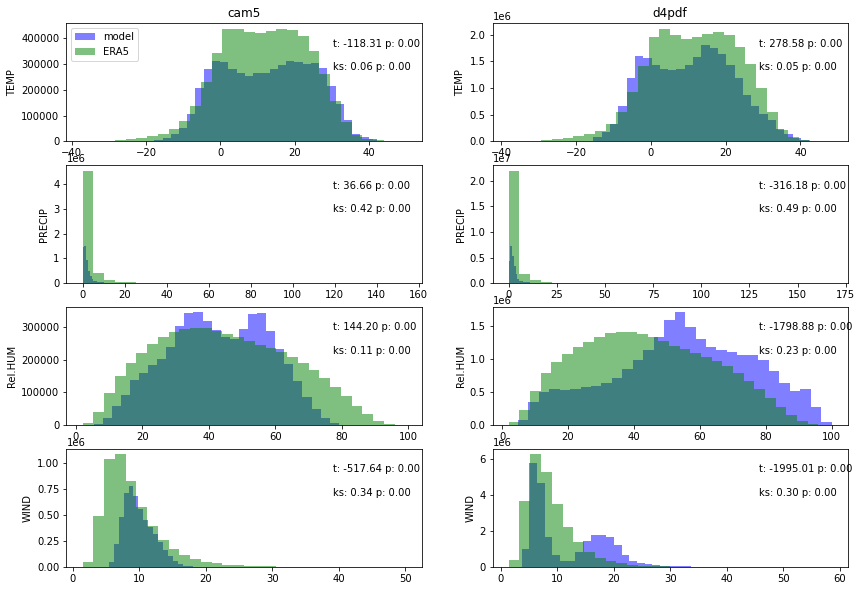

In [48]:
var_names = {'d4pdf':['ta','precipi','rha','wind'],'cam5':['tasmax','pr','rh','wind'],'era5':['mx2t','tp','min_rh','wind']}
cb_ranges = {'TEMP':[0,30],'PRECIP':[0,10],'Rel.HUM':[20,75],'WIND':[0,25]}
images = {}

fig,axs = plt.subplots(4,2,figsize=(14,10))

model = 'd4pdf'
for i,var in enumerate(['TEMP','PRECIP','Rel.HUM','WIND']):
    
    for j,model in enumerate(['cam5','d4pdf']):
        if model == 'd4pdf':
            model_data = d4pdf_vars[var_names[model][i]].sel(time=slice('1951','2021')).data.flatten()
            era5_data = era5_d4pdf_res[var_names['era5'][i]].sel(time=slice('1951','2021')).data.flatten()
            
        elif model == 'cam5':
            model_data = cam5_vars[var_names[model][i]].sel(time=slice('1959','2014')).data.flatten()
            era5_data = era5_cam5_res[var_names['era5'][i]].sel(time=slice('1959','2014')).data.flatten()
            
        model_data = model_data[~np.isnan(model_data)]
        era5_data = era5_data[~np.isnan(era5_data)]

        axs[i][j].hist(model_data,label='model',color='blue',alpha=0.5,bins=30)
        axs[i][j].hist(era5_data,label='ERA5',color='green',alpha=0.5,bins=30)
        
        t_stat, t_p_value = stats.ttest_ind(era5_data,model_data)
        ks_stat, ks_p_value = stats.kstest(era5_data,model_data)

        axs[i][j].text(0.75,0.8,f't: {t_stat:.2f} p: {t_p_value:.2f}',transform=axs[i][j].transAxes)
        axs[i][j].text(0.75,0.6,f'ks: {ks_stat:.2f} p: {ks_p_value:.2f}',transform=axs[i][j].transAxes)
        
        if i == 0:
            axs[i][j].set_title(model)
            if j == 0:
                axs[i][j].legend(loc='upper left')
            
        axs[i][j].set_ylabel(var)
        


In [ ]:


'''
# clip to time windows
cam5_vars = cam5_vars.sel(time=slice('1959','2014'))
cam5_vars = cam5_vars.resample(time='1D').first()
era5_cam5_res = era5_cam5_res.sel(time=slice('1959','2014'))
era5_cam5_res = era5_cam5_res.sel(time=~((era5_cam5_res.time.dt.month == 2) & (era5_cam5_res.time.dt.day == 29)))

d4pdf_vars = d4pdf_vars.sel(time=slice('1951','2021'))
era5_d4pdf_res = era5_d4pdf_res.sel(time=slice('1951','2021'))
'''


'''
era5_vars = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/daily/inputs_1951-2021.nc')
era5_vars = era5_vars.rename({'latitude':'lat','longitude':'lon'})
era5_vars['lon'] = [lon + 360 for lon in era5_vars.lon.data]

# coarsen + interp ERA5 to model resolutions
print('coarsening ERA5')
era5_coarsened = era5_vars.coarsen(lat=3,lon=3,boundary='pad').mean()

print('interpolating ERA5 to model grids')
era5_d4pdf_res = era5_coarsened.interp(lon=d4pdf_vars.lon, lat=d4pdf_vars.lat, method="linear")
era5_cam5_res = era5_coarsened.interp(lon=cam5_vars.lon, lat=cam5_vars.lat, method="linear")

era5_cam5_res.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/daily/cam5_resolution/FWI_inputs_daily_cam5_resolution.nc')
era5_d4pdf_res.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/daily/d4pdf_resolution/FWI_inputs_daily_d4pdf_resolution.nc')
'''